In [3]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np 
import pandas as pd 
from pandas import DataFrame
import matplotlib.pyplot as plt

In [5]:

from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf

from sklearn.metrics import mean_squared_error

get_ipython().run_line_magic('matplotlib', 'inline')

In [17]:
df = pd.read_csv("C:\\Users\\saura\\Downloads\\AAPL.csv", parse_dates=['Date'])
df.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,1998-11-30,1.234375,1.243304,1.133929,1.140625,0.763834,140372400
1,1998-12-01,1.142857,1.243304,1.129464,1.218750,0.816152,216434400
2,1998-12-02,1.218750,1.316964,1.196429,1.285714,0.860995,240620800


In [19]:
print (df.describe())
print ("=============================================================")
print (df.dtypes)

                                Date         Open         High          Low  \
count                           5033  5033.000000  5033.000000  5033.000000   
mean   2008-11-30 10:19:08.738327040    48.474497    48.929859    47.989695   
min              1998-11-30 00:00:00     0.927857     0.942143     0.908571   
25%              2003-12-02 00:00:00     3.160714     3.276786     3.071429   
50%              2008-12-01 00:00:00    22.700001    23.171429    22.357143   
75%              2013-11-29 00:00:00    84.620003    85.278572    83.765717   
max              2018-11-28 00:00:00   230.779999   233.470001   229.779999   
std                              NaN    55.141765    55.592274    54.685168   

             Close    Adj Close        Volume  
count  5033.000000  5033.000000  5.033000e+03  
mean     48.470623    42.320780  1.207779e+08  
min       0.937143     0.627570  9.835000e+06  
25%       3.194196     2.139034  5.413940e+07  
50%      22.840000    15.295103  9.420460e+07  


In [21]:
df1 = df[['Date','Close']]
df1.head(3)

,Date,Close
0,1998-11-30,1.140625
1,1998-12-01,1.218750
2,1998-12-02,1.285714


In [23]:
df_ts = df1.set_index('Date')
df_ts.sort_index(inplace=True)
print (type(df_ts))
print (df_ts.head(3))
print ("========================")
print (df_ts.tail(3))

<class 'pandas.core.frame.DataFrame'>
               Close
Date                
1998-11-30  1.140625
1998-12-01  1.218750
1998-12-02  1.285714
                 Close
Date                  
2018-11-26  174.619995
2018-11-27  174.240005
2018-11-28  180.940002


In [25]:
df_ts[df_ts.isnull()]

,Close
Date,
1998-11-30,NaN
1998-12-01,NaN
1998-12-02,NaN
1998-12-03,NaN
1998-12-04,NaN
...,...
2018-11-21,NaN
2018-11-23,NaN
2018-11-26,NaN


In [27]:
len(df_ts[df_ts.isnull()])

5033

In [29]:
df_ts = df_ts.sort_index()
df_ts.index

DatetimeIndex(['1998-11-30', '1998-12-01', '1998-12-02', '1998-12-03',
               '1998-12-04', '1998-12-07', '1998-12-08', '1998-12-09',
               '1998-12-10', '1998-12-11',
               ...
               '2018-11-14', '2018-11-15', '2018-11-16', '2018-11-19',
               '2018-11-20', '2018-11-21', '2018-11-23', '2018-11-26',
               '2018-11-27', '2018-11-28'],
              dtype='datetime64[ns]', name='Date', length=5033, freq=None)

In [31]:
df_ts.Close.fillna(method='pad', inplace=True)



In [33]:
df_ts[df_ts.Close.isnull()]
len(df_ts[df_ts.Close.isnull()])

0

In [35]:

df_ts.plot()

<Axes: xlabel='Date'>

In [37]:
def test_stationarity(timeseries):
    # Perform Dickey-Fuller test:
    from statsmodels.tsa.stattools import adfuller
    print('Results of Dickey-Fuller Test:')
    print ("==============================================")
    
    dftest = adfuller(timeseries, autolag='AIC')
    
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    
    print(dfoutput)

In [39]:
ts = df_ts['Close']
test_stationarity(ts)

Results of Dickey-Fuller Test:
Test Statistic                    0.801293
p-value                           0.991657
#lags Used                       31.000000
Number of Observations Used    5001.000000
Critical Value (1%)              -3.431658
Critical Value (5%)              -2.862118
Critical Value (10%)             -2.567078
dtype: float64


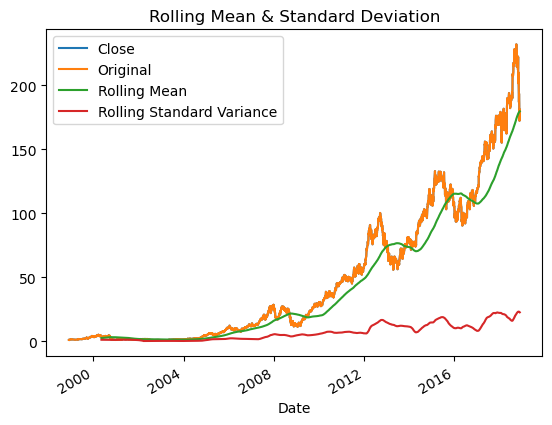

In [41]:
rolmean = ts.rolling(window=365).mean()
rolvar = ts.rolling(window=365).std()

plt.plot(ts, label='Original')
plt.plot(rolmean, label='Rolling Mean')
plt.plot(rolvar, label='Rolling Standard Variance')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show(block=False)

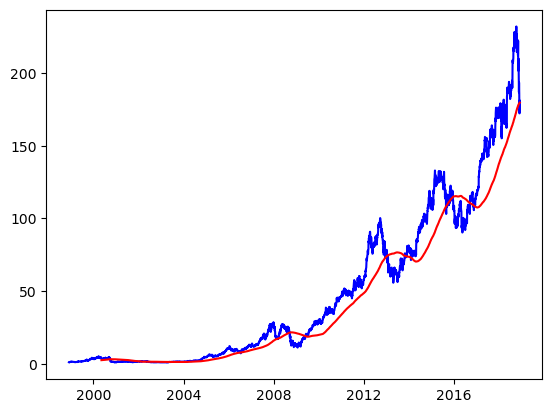

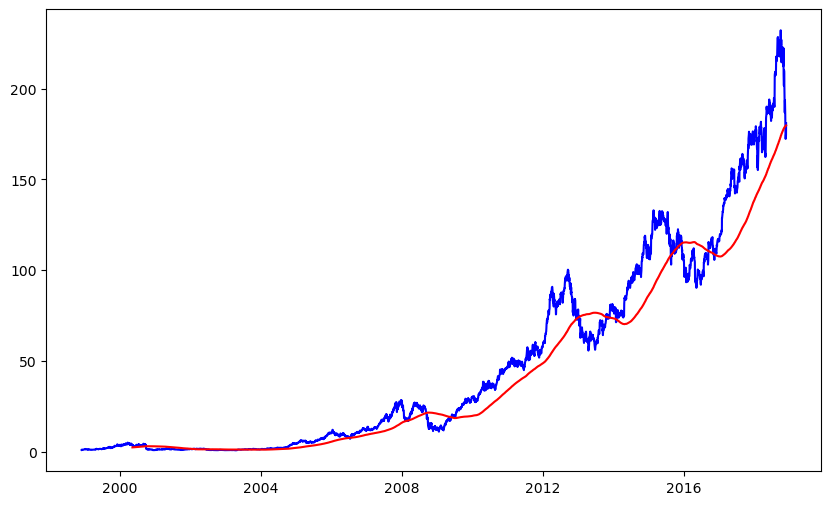

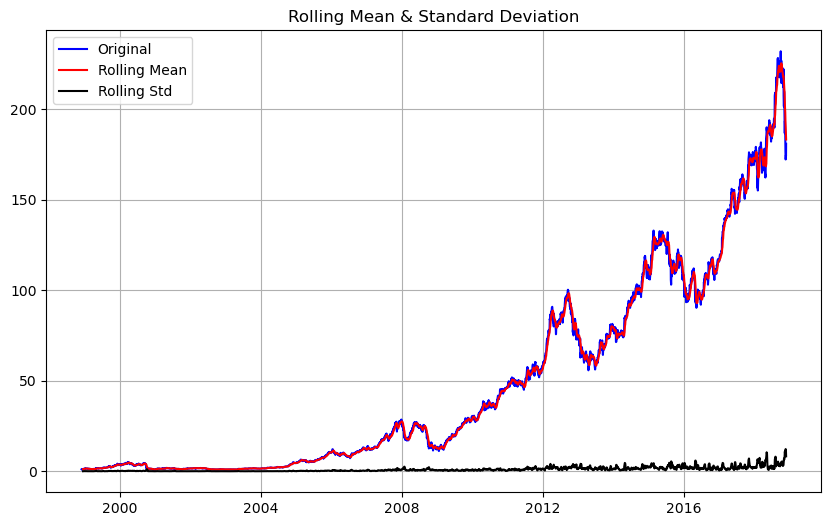

In [47]:
import matplotlib.pyplot as plt

rolmean = ts.rolling(window=12).mean()
rolstd = ts.rolling(window=12).std()

plt.figure(figsize=(10, 6))
plt.plot(ts, color='blue', label='Original')
plt.plot(rolmean, color='red', label='Rolling Mean')
plt.plot(rolstd, color='black', label='Rolling Std')

plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.grid(True)
plt.show()

In [49]:
ts.dropna(inplace=True)
ts.head(5)
from statsmodels.tsa.stattools import adfuller

In [51]:
print('results of dikey-fuller test:')
dftest=adfuller(ts, autolag='AIC')


results of dikey-fuller test:


In [53]:
dfoutput=pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#lags Used', '#observations'])
for key,value in dftest[4].items():
    dfoutput['Critical value (%s)'%key]=value
    
print (dfoutput)


Test Statistic             0.801293
p-value                    0.991657
#lags Used                31.000000
#observations           5001.000000
Critical value (1%)       -3.431658
Critical value (5%)       -2.862118
Critical value (10%)      -2.567078
dtype: float64


In [55]:
ts_logScale=np.log(ts)
plt.plot(ts_logScale)


In [57]:
movingAverage=ts_logScale.rolling(window=12).mean()
movingSTD=ts_logScale.rolling(window=12).std()
plt.plot(ts_logScale)
plt.plot(movingAverage, color='red')

In [59]:
ts_LogScaleMinusMA=ts_logScale-movingAverage
ts_LogScaleMinusMA.head(12)
ts_LogScaleMinusMA.dropna(inplace=True)
ts_LogScaleMinusMA.head(10)

Date
1998-12-15    0.012149
1998-12-16   -0.012704
1998-12-17    0.007861
1998-12-18    0.060776
1998-12-21    0.053884
1998-12-22    0.121948
1998-12-23    0.154775
1998-12-24    0.123691
1998-12-28    0.143859
1998-12-29    0.122058
Name: Close, dtype: float64

In [73]:
def est_stationarity(timeseries):
    # same function body as before

    # Rolling statistics
    movingAverage = timeseries.rolling(window=12).mean()
    movingSTD = timeseries.rolling(window=12).std()

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(timeseries, color='blue', label='Original')
    plt.plot(movingAverage, color='red', label='Rolling Mean')
    plt.plot(movingSTD, color='black', label='Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.grid(True)
    plt.show(block=False)   # <-- use this if plt.show() blocks

    # Dickey-Fuller Test
    print("\n=== Augmented Dickey-Fuller Test ===")
    dftest = adfuller(timeseries.dropna(), autolag='AIC')

    dfoutput = pd.Series(dftest[0:4],
                         index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value

    print(dfoutput.to_string())  # ensures proper console output


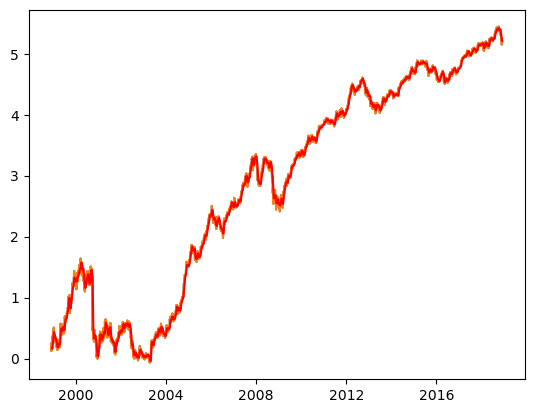

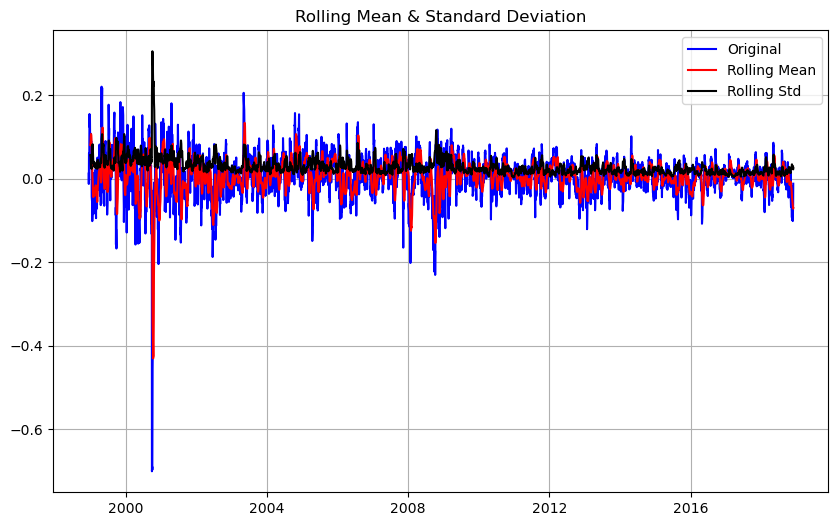


=== Augmented Dickey-Fuller Test ===
Test Statistic                -1.298667e+01
p-value                        2.868709e-24
#Lags Used                     2.100000e+01
Number of Observations Used    5.000000e+03
Critical Value (1%)           -3.431659e+00
Critical Value (5%)           -2.862118e+00
Critical Value (10%)          -2.567078e+00


In [75]:
est_stationarity(ts_LogScaleMinusMA)

In [77]:
exponentialDecayWeightedAverage=ts_logScale.ewm(halflife=12, min_periods=0, adjust=True).mean()
plt.plot(ts_logScale)
plt.plot(exponentialDecayWeightedAverage, color='red')


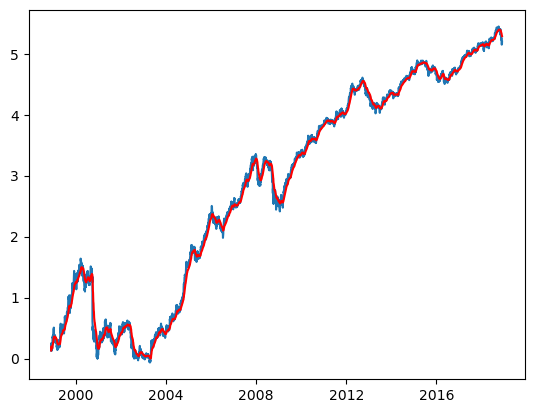

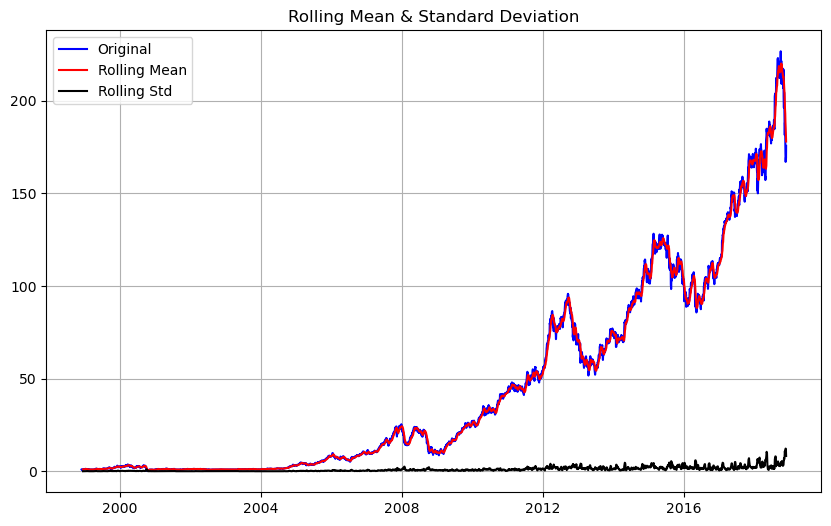


=== Augmented Dickey-Fuller Test ===
Test Statistic                    0.803416
p-value                           0.991691
#Lags Used                       31.000000
Number of Observations Used    5001.000000
Critical Value (1%)              -3.431658
Critical Value (5%)              -2.862118
Critical Value (10%)             -2.567078


In [81]:
ts_LogScaleMinusExponentialDecayAverage = ts - exponentialDecayWeightedAverage
test_stationarity(ts_LogScaleMinusExponentialDecayAverage)


In [83]:
ts_LogDiffShifting= ts_logScale-ts_logScale.shift()
plt.plot(ts_LogDiffShifting)

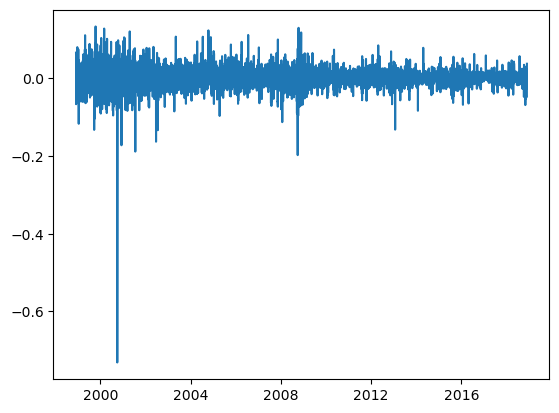

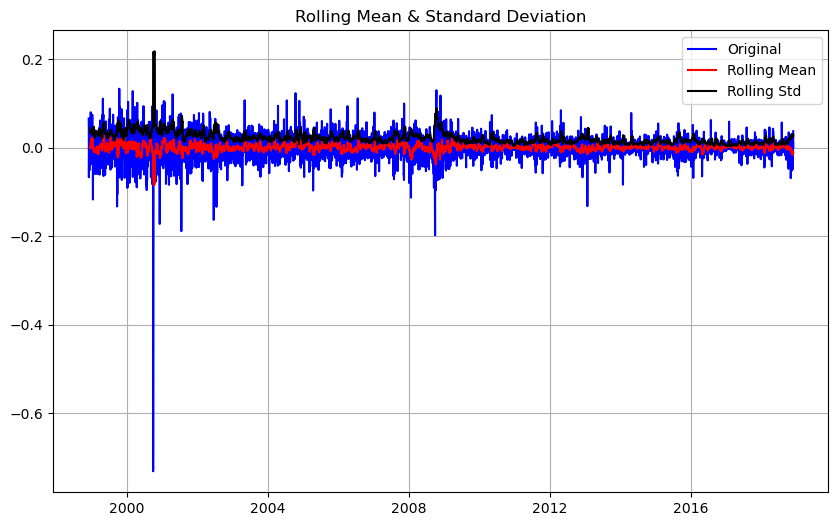


=== Augmented Dickey-Fuller Test ===
Test Statistic                -1.520099e+01
p-value                        5.830139e-28
#Lags Used                     2.000000e+01
Number of Observations Used    5.011000e+03
Critical Value (1%)           -3.431656e+00
Critical Value (5%)           -2.862117e+00
Critical Value (10%)          -2.567077e+00


In [85]:
ts_LogDiffShifting.dropna(inplace=True)
test_stationarity(ts_LogDiffShifting)


In [87]:
ts_logScale.head()

Date
1998-11-30    0.131576
1998-12-01    0.197826
1998-12-02    0.251314
1998-12-03    0.184922
1998-12-04    0.156699
Name: Close, dtype: float64

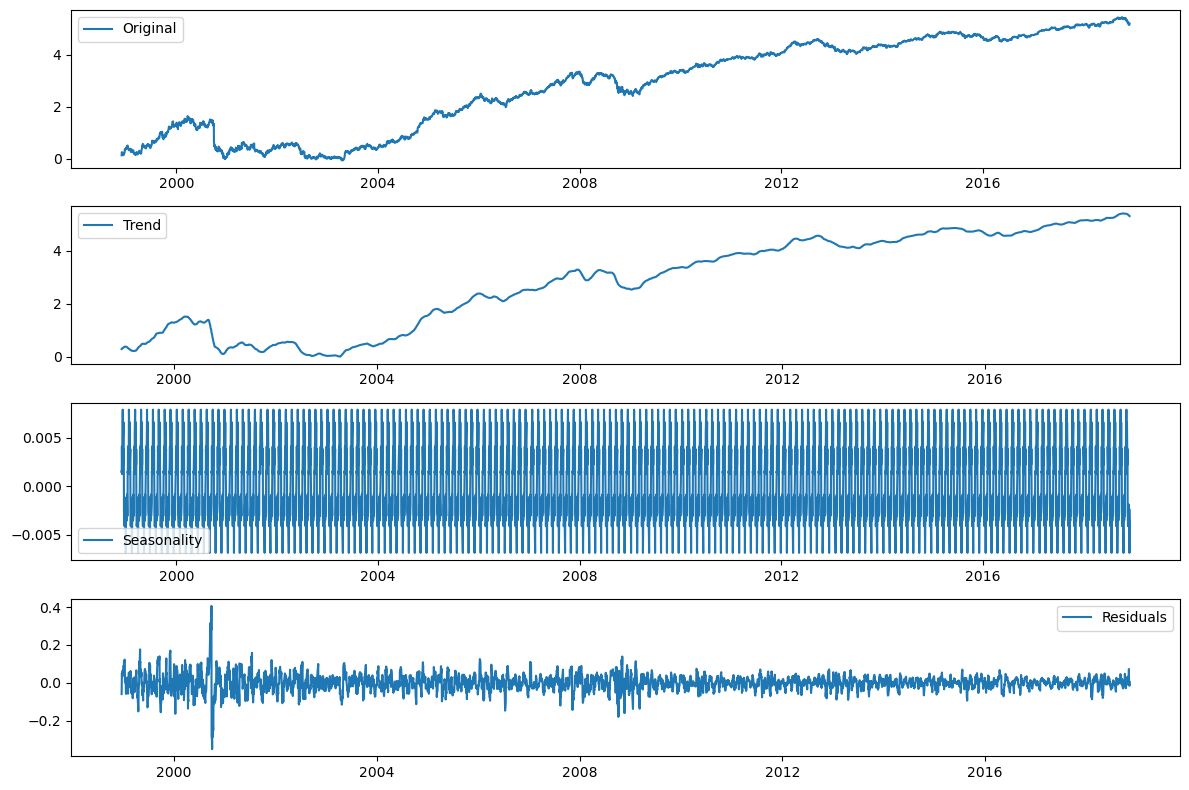

In [91]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts_logScale.dropna(inplace=True)
decomposition = seasonal_decompose(ts_logScale, period=30)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot components
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.subplot(411)
plt.plot(ts_logScale, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


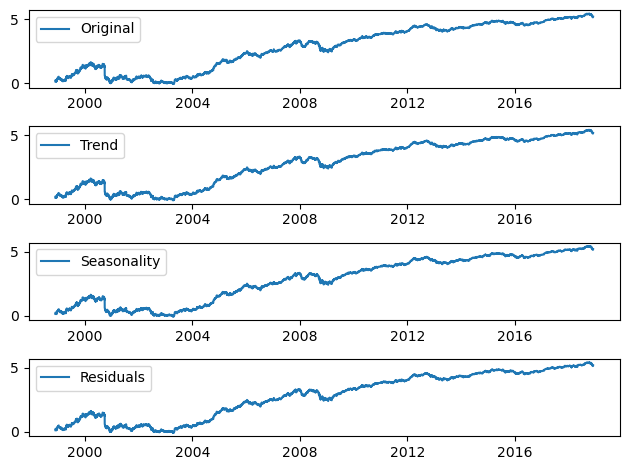

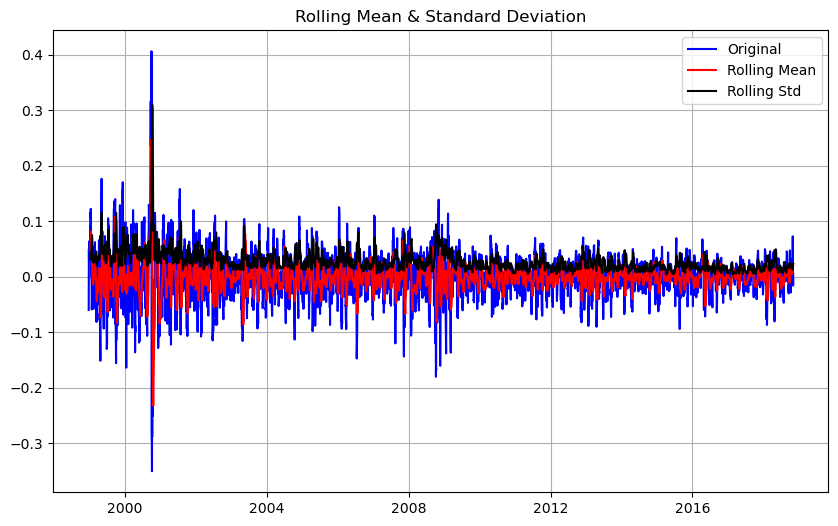


=== Augmented Dickey-Fuller Test ===
Test Statistic                -1.877137e+01
p-value                        2.025167e-30
#Lags Used                     3.200000e+01
Number of Observations Used    4.970000e+03
Critical Value (1%)           -3.431666e+00
Critical Value (5%)           -2.862122e+00
Critical Value (10%)          -2.567080e+00


In [93]:
plt.subplot(411)
plt.plot(ts_logScale, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(ts_logScale, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(ts_logScale, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(ts_logScale, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
decomposedLogData=residual
decomposedLogData.dropna(inplace=True)
test_stationarity(decomposedLogData)



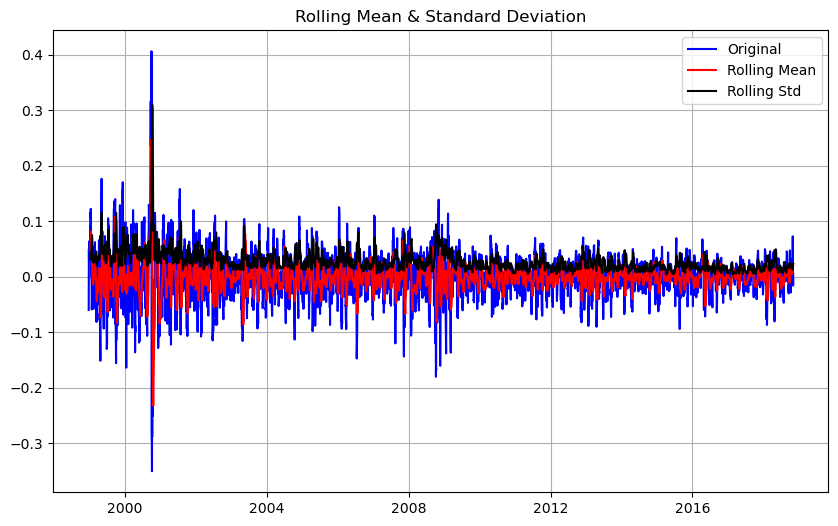


=== Augmented Dickey-Fuller Test ===
Test Statistic                -1.877137e+01
p-value                        2.025167e-30
#Lags Used                     3.200000e+01
Number of Observations Used    4.970000e+03
Critical Value (1%)           -3.431666e+00
Critical Value (5%)           -2.862122e+00
Critical Value (10%)          -2.567080e+00


In [96]:

decomposedLogData=residual
decomposedLogData.dropna(inplace=True)
test_stationarity(decomposedLogData)


In [98]:
from statsmodels.tsa.stattools import acf, pacf

lag_acf=acf(ts_LogDiffShifting, nlags=20)
lag_pacf=pacf(ts_LogDiffShifting, nlags=20, method='ols')

In [100]:
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y=0, linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_LogDiffShifting)), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_LogDiffShifting)), linestyle='--', color='gray')
plt.title('Autocorrelation Function')
plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y=0, linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_LogDiffShifting)), linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_LogDiffShifting)), linestyle='--', color='gray')
plt.title('Partial Autocorrelation Function')
plt.tight_layout()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


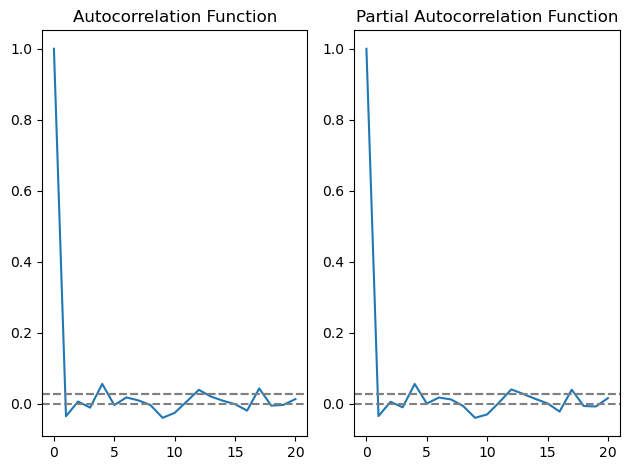

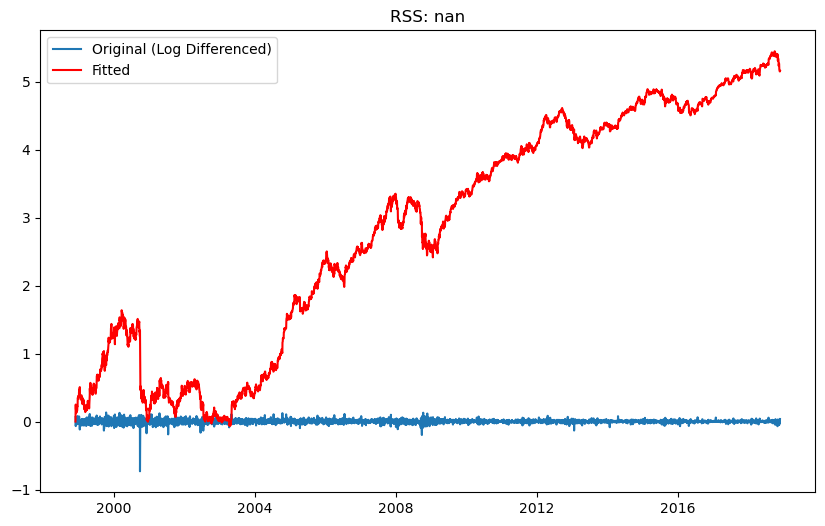

In [104]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Fit ARIMA model
model = ARIMA(ts_logScale, order=(1, 1, 1))
results_AR = model.fit()

# Plot results
plt.figure(figsize=(10,6))
plt.plot(ts_LogDiffShifting, label="Original (Log Differenced)")
plt.plot(results_AR.fittedvalues, color='red', label="Fitted")
plt.title(f'RSS: {sum((results_AR.fittedvalues - ts_LogDiffShifting)**2):.4f}')
plt.legend()
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


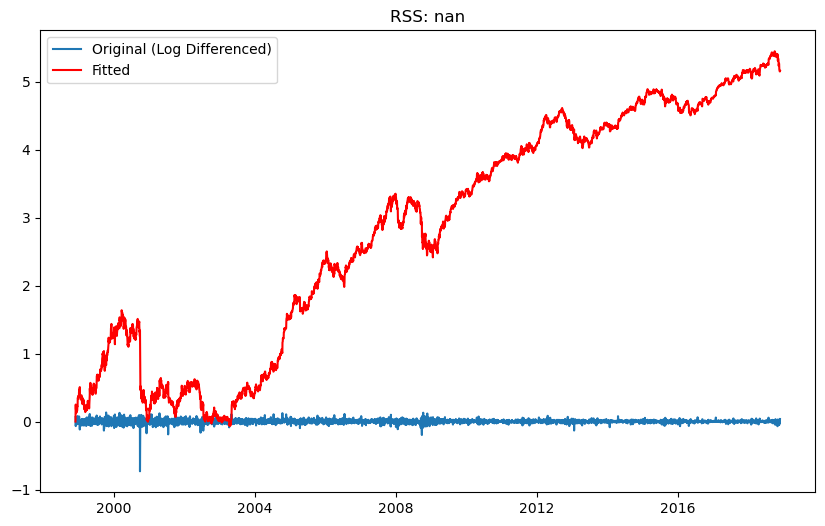

In [108]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Fit ARIMA model
model = ARIMA(ts_logScale, order=(1,1,1))
results_ARIMA = model.fit()

# Plot actual differenced vs fitted values
plt.figure(figsize=(10,6))
plt.plot(ts_LogDiffShifting, label="Original (Log Differenced)")
plt.plot(results_ARIMA.fittedvalues, color='red', label="Fitted")
plt.title(f'RSS: {sum((results_ARIMA.fittedvalues - ts_LogDiffShifting)**2):.4f}')
plt.legend()
plt.show()


In [110]:
predicitons_ARIMA_diff=pd.Series(results_ARIMA.fittedvalues, copy=True)
print(predicitons_ARIMA_diff.head())

Date
1998-11-30    0.000000
1998-12-01    0.131576
1998-12-02    0.195632
1998-12-03    0.250178
1998-12-04    0.187419
dtype: float64


In [112]:
predicitons_ARIMA_diff_cumsum=predicitons_ARIMA_diff.cumsum()
print(predicitons_ARIMA_diff_cumsum)

Date
1998-11-30        0.000000
1998-12-01        0.131576
1998-12-02        0.327208
1998-12-03        0.577386
1998-12-04        0.764805
                  ...     
2018-11-21    14191.889425
2018-11-23    14197.064022
2018-11-26    14202.214131
2018-11-27    14207.376041
2018-11-28    14212.536744
Length: 5033, dtype: float64


In [116]:
predictions_ARIMA_log = pd.Series(ts_logScale.iloc[0], index=ts_logScale.index)
predictions_ARIMA_log = predictions_ARIMA_log.add(predicitons_ARIMA_diff_cumsum, fill_value=0)


In [118]:
predictions_ARIMA_log.head()

Date
1998-11-30    0.131576
1998-12-01    0.263153
1998-12-02    0.458784
1998-12-03    0.708962
1998-12-04    0.896382
dtype: float64

In [120]:
predicitons_ARIMA=np.exp(predictions_ARIMA_log)
plt.plot(ts)
plt.plot(predicitons_ARIMA)


In [122]:
ts_logScale

Date
1998-11-30    0.131576
1998-12-01    0.197826
1998-12-02    0.251314
1998-12-03    0.184922
1998-12-04    0.156699
                ...   
2018-11-21    5.174906
2018-11-23    5.149179
2018-11-26    5.162612
2018-11-27    5.160434
2018-11-28    5.198165
Name: Close, Length: 5033, dtype: float64

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


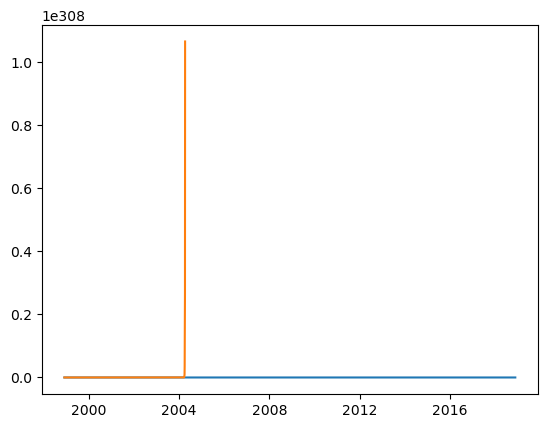

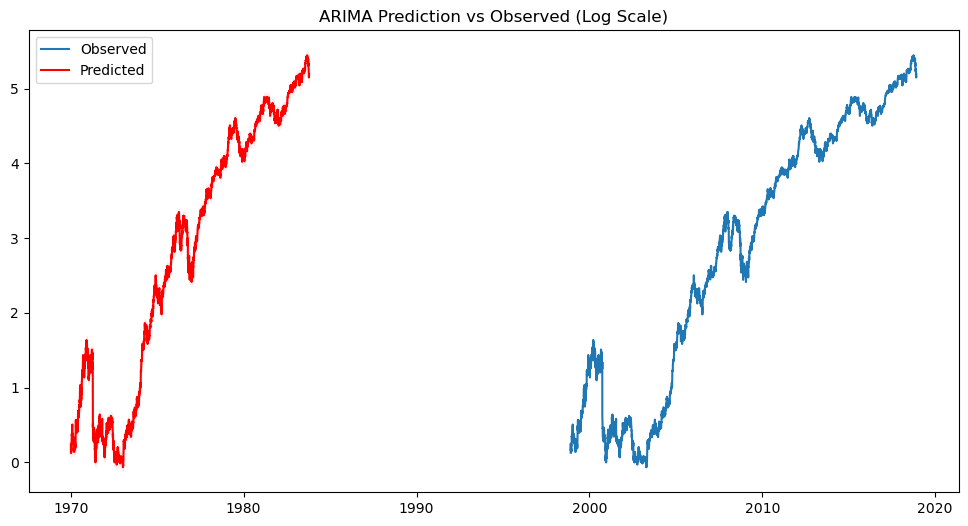

In [126]:
# In-sample prediction (like plot_predict)
pred = results_ARIMA.get_prediction(start=1, end=len(ts_logScale))
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

plt.figure(figsize=(12,6))
plt.plot(ts_logScale, label="Observed")
plt.plot(pred_mean, color="red", label="Predicted")
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1], color="pink", alpha=0.3)
plt.legend()
plt.title("ARIMA Prediction vs Observed (Log Scale)")
plt.show()


In [128]:
results_ARIMA.forecast(14)

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


5033    5.196853
5034    5.197266
5035    5.197136
5036    5.197177
5037    5.197164
5038    5.197168
5039    5.197167
5040    5.197167
5041    5.197167
5042    5.197167
5043    5.197167
5044    5.197167
5045    5.197167
5046    5.197167
Name: predicted_mean, dtype: float64